<h1> Install Library

In [ ]:
!pip install scipy

<h1> Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

plt.rcParams['figure.figsize'] = (10,6)
sns.set_style("whitegrid")

<h1> EDA

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/China_profile_dataset_20250710.csv")
df.head()

,Samples,profile_id,latitude,longitude,BD (g/cm3),SOC (g/kg),SOCD (kg/m2),upper_dept,lower_dept,Depth,...,PET,AI,pH,Sand,Silt,Clay,CLCD,SOCD__meth,References,Year
0,1,1,31.486306,118.514028,1.15,18.16,2.92,0,14,7.0,...,1259.87,0.89,6.25,41.55,34.27,62.51,1,Measurement,"Liu et al., 2022",2014
1,2,1,31.486306,118.514028,1.33,14.44,1.54,14,22,18.0,...,1259.87,0.89,6.43,39.79,31.51,64.32,1,Measurement,"Liu et al., 2022",2014
2,3,1,31.486306,118.514028,1.53,3.88,2.55,22,65,43.5,...,1259.87,0.89,6.72,42.50,26.63,67.25,1,Measurement,"Liu et al., 2022",2014
3,4,1,31.486306,118.514028,1.23,10.61,4.96,65,103,84.0,...,1259.87,0.89,6.81,37.68,30.09,68.10,1,Measurement,"Liu et al., 2022",2014
4,5,2,31.006889,116.908722,1.24,25.23,5.32,0,17,8.5,...,1289.22,1.13,6.06,48.55,29.42,60.60,1,Measurement,"Liu et al., 2022",2014


In [ ]:
print("Shape dataset:", df.shape)
print("\nInfo dataset:")
df.info()

print("\nStatistik deskriptif numerik:")
df.describe()

print("\nStatistik deskriptif kategorikal:")
df.describe(include='object')

Shape dataset: (23103, 24)

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23103 entries, 0 to 23102
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Samples       23103 non-null  int64  
 1   profile_id    23103 non-null  int64  
 2   latitude      23103 non-null  float64
 3   longitude     23103 non-null  float64
 4   BD (g/cm3)    23103 non-null  float64
 5   SOC (g/kg)    23103 non-null  float64
 6   SOCD (kg/m2)  23103 non-null  float64
 7   upper_dept    23103 non-null  int64  
 8   lower_dept    23103 non-null  int64  
 9   Depth         23103 non-null  float64
 10  DEM           23103 non-null  object 
 11  NDVI          23103 non-null  object 
 12  MAT           23103 non-null  object 
 13  MAP           23103 non-null  object 
 14  PET           23103 non-null  object 
 15  AI            23103 non-null  object 
 16  pH            23103 non-null  object 
 17  Sand          23103 non-nul

,DEM,NDVI,MAT,MAP,PET,AI,pH,Sand,Silt,Clay,SOCD__meth,References
count,23103,23103,23103,23103,23103,23103,23103,23103,23103,23103,23103,23103
unique,7003,97,2621,4235,4611,194,557,6275,5637,4551,2,30
top,4.00,(9999.00),(9999.00),(9999.00),(9999.00),0.35,8.17,(999.90),(999.90),(999.90),Measurement,"Liu et al., 2022"
freq,187,805,101,101,126,470,145,101,101,101,18058,17289


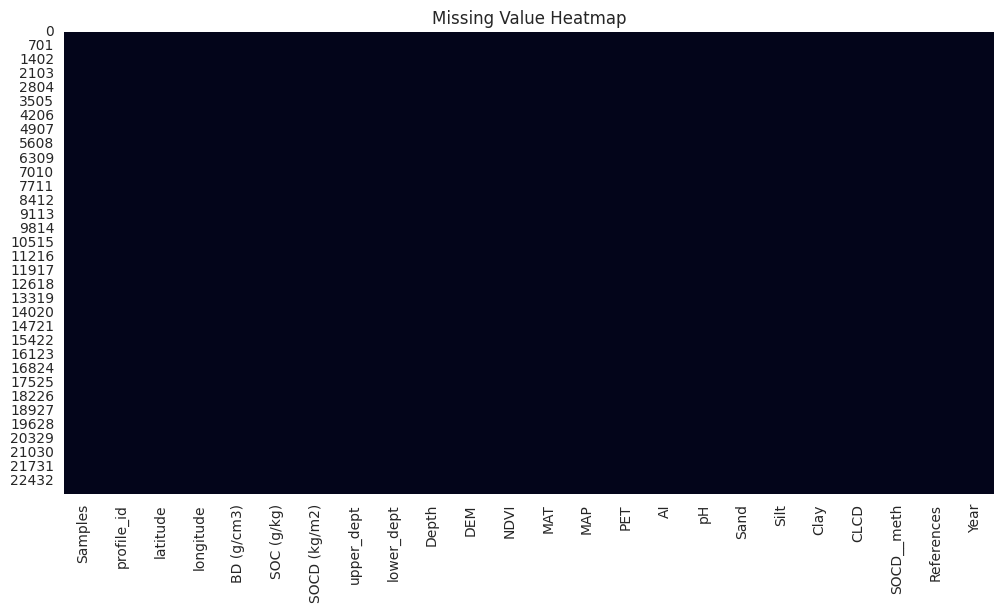

In [ ]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percent (%)': missing_percent
})

missing_df[missing_df['Missing Count'] > 0]

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

<h1> Prepocessing

In [ ]:
cols_numeric = [
    "DEM", "NDVI", "MAT", "MAP", "PET",
    "AI", "pH", "Sand", "Silt", "Clay"
]

for col in cols_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=cols_numeric)
df = df[~df["CLCD"].isin([9999, -9999])]

In [ ]:
if "SOCD (kg/m2)"in df.columns:
  df["SOCD (kg/m2)"] = df["SOCD (kg/m2)"] * 10
  df.rename(columns={"SOCD (kg/m2)": "SOCS"}, inplace=True)

print(df)

       Samples  profile_id   latitude   longitude  BD (g/cm3)  SOC (g/kg)  \
0            1           1  31.486306  118.514028        1.15       18.16   
1            2           1  31.486306  118.514028        1.33       14.44   
2            3           1  31.486306  118.514028        1.53        3.88   
3            4           1  31.486306  118.514028        1.23       10.61   
4            5           2  31.006889  116.908722        1.24       25.23   
...        ...         ...        ...         ...         ...         ...   
23098    23099        7039  24.300000  113.933333        1.25        0.00   
23099    23100        7039  24.300000  113.933333        1.24        0.00   
23100    23101        7039  24.300000  113.933333        1.48        0.00   
23101    23102        9143  19.650000  110.683333        0.90        0.00   
23102    23103        9143  19.650000  110.683333        1.14        0.00   

        SOCS  upper_dept  lower_dept  Depth  ...      PET    AI    pH   San

In [ ]:
drop_column = ["Samples", "profile_id", "latitude", "longitude", "References"]
print (drop_column)

if "Samples"in df.columns:
  df = df.drop(columns=list(drop_column))
df.shape

['Samples', 'profile_id', 'latitude', 'longitude', 'References']


(19438, 19)

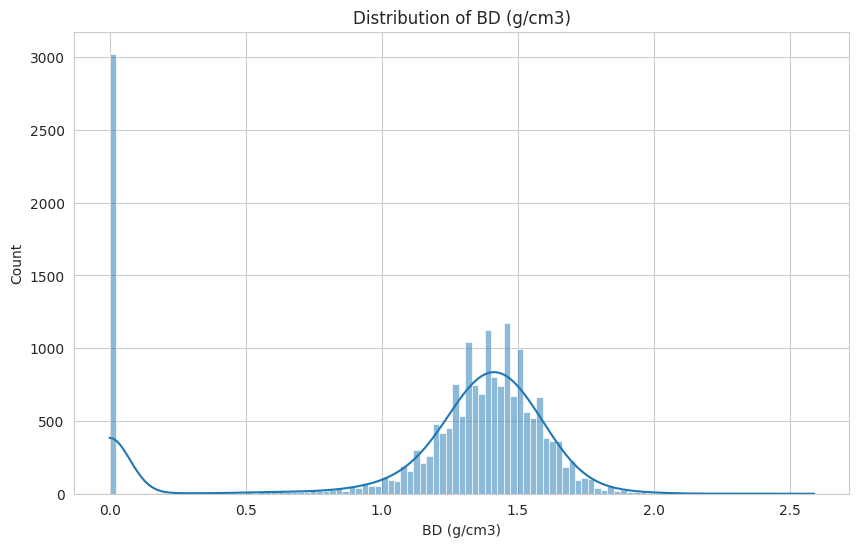

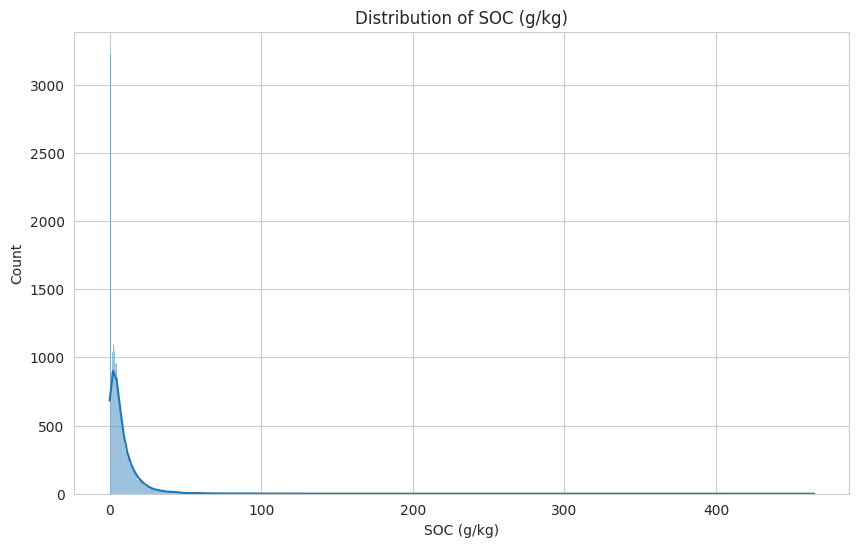

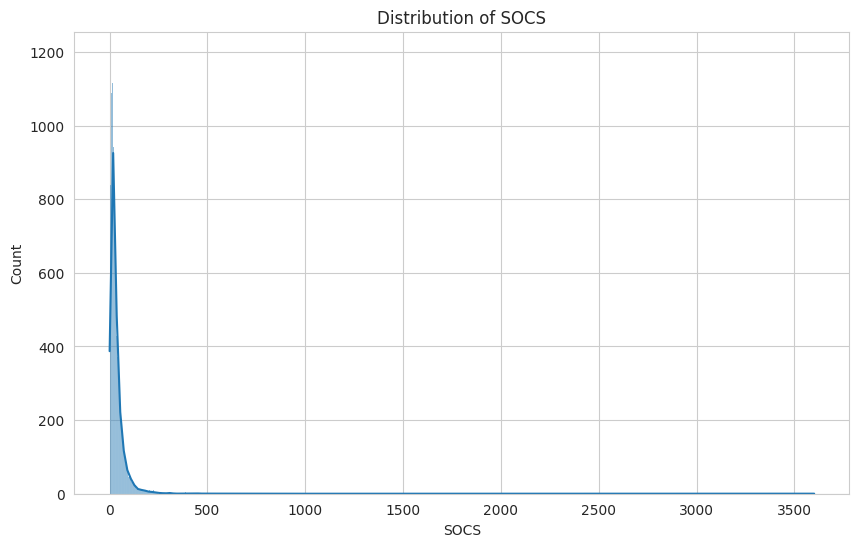

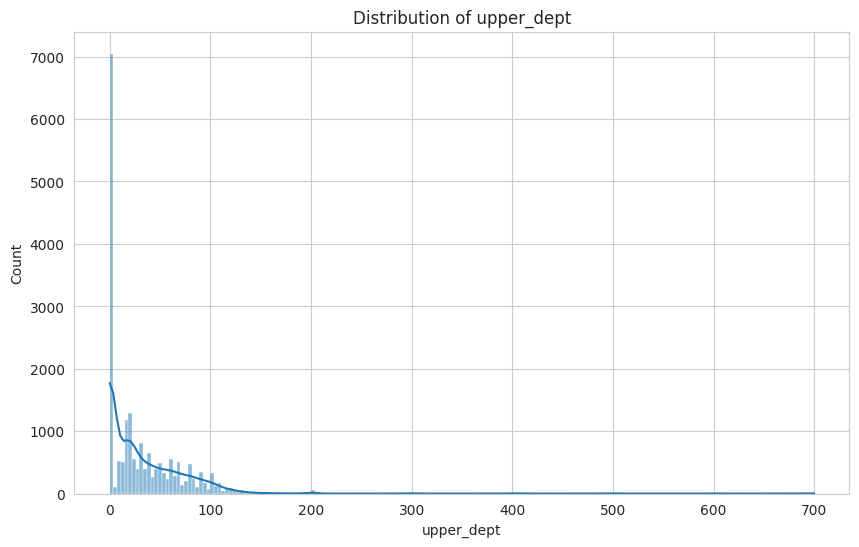

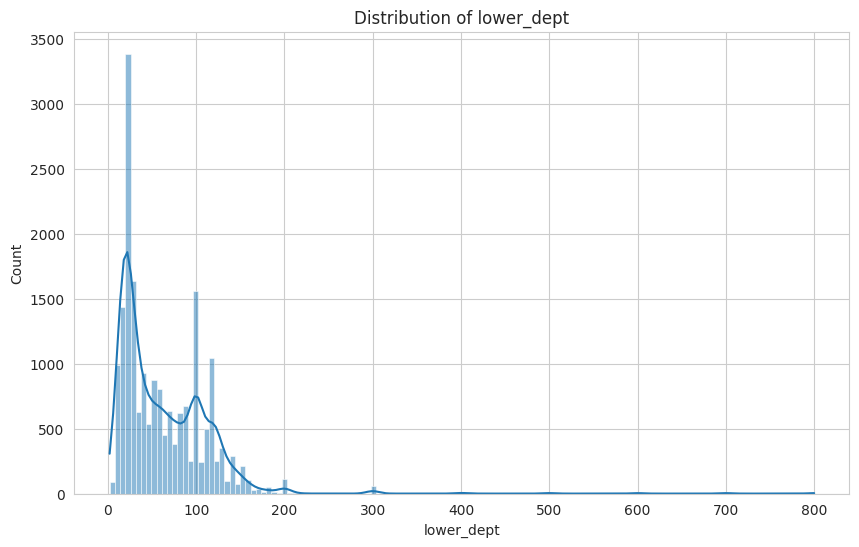

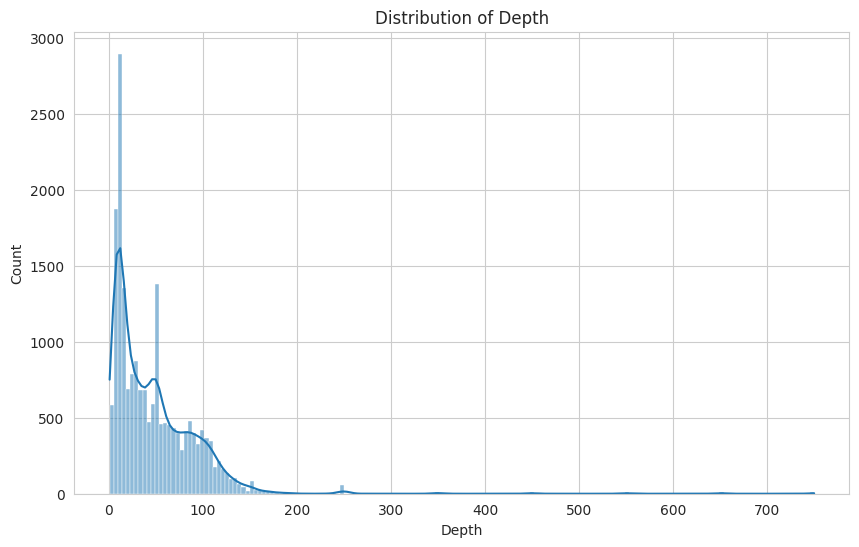

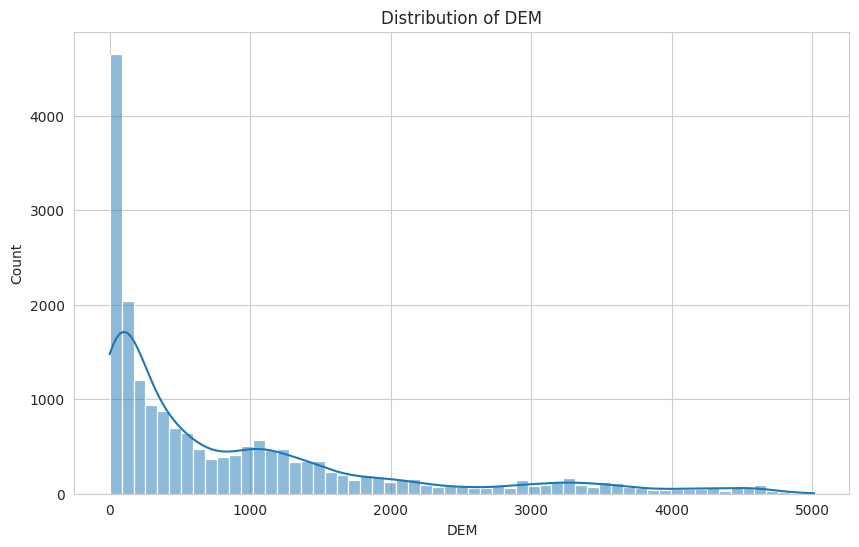

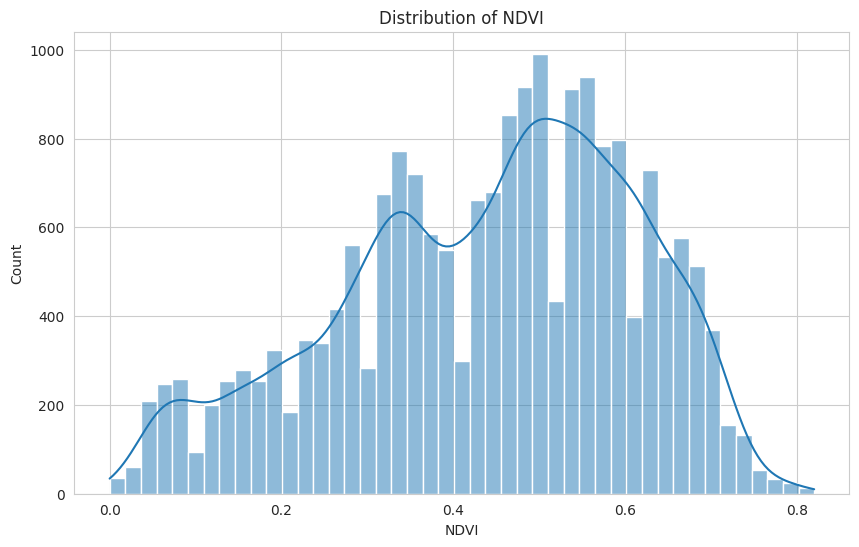

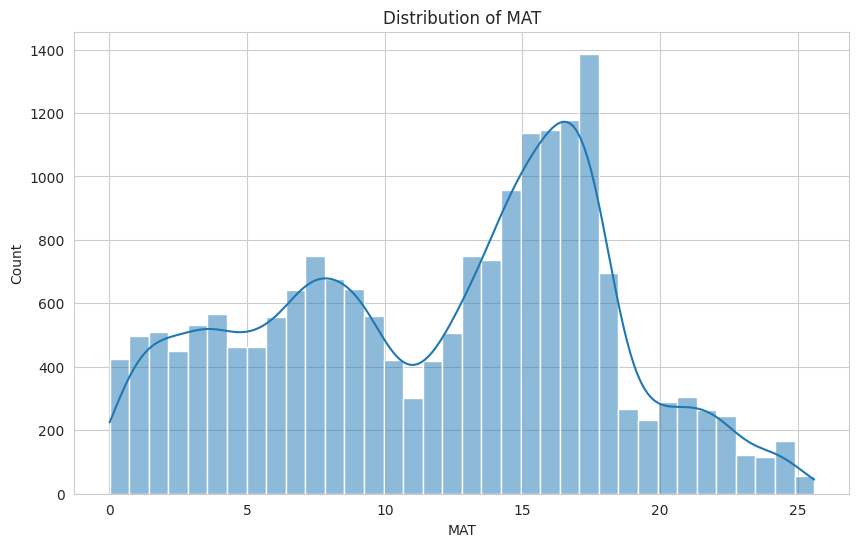

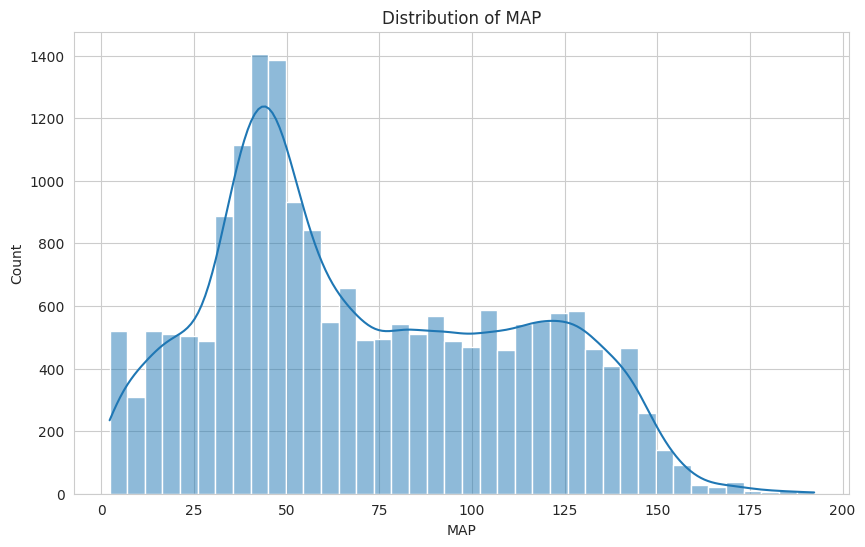

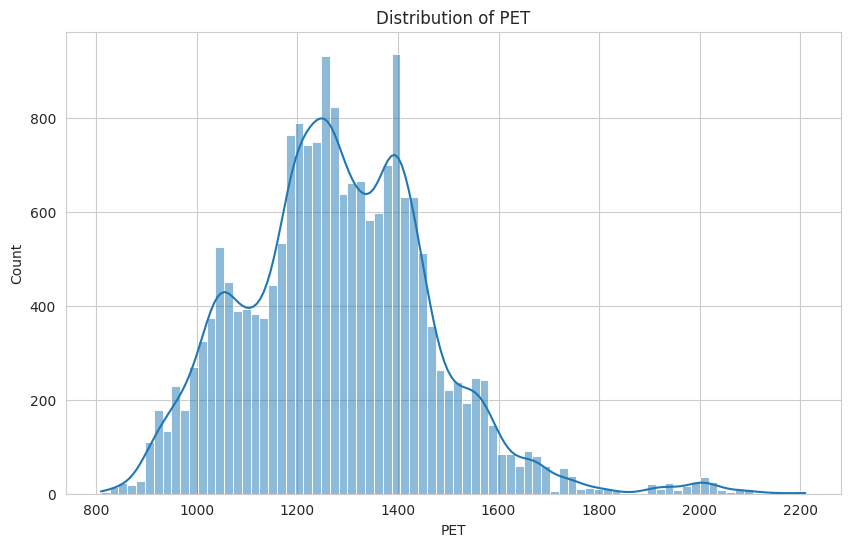

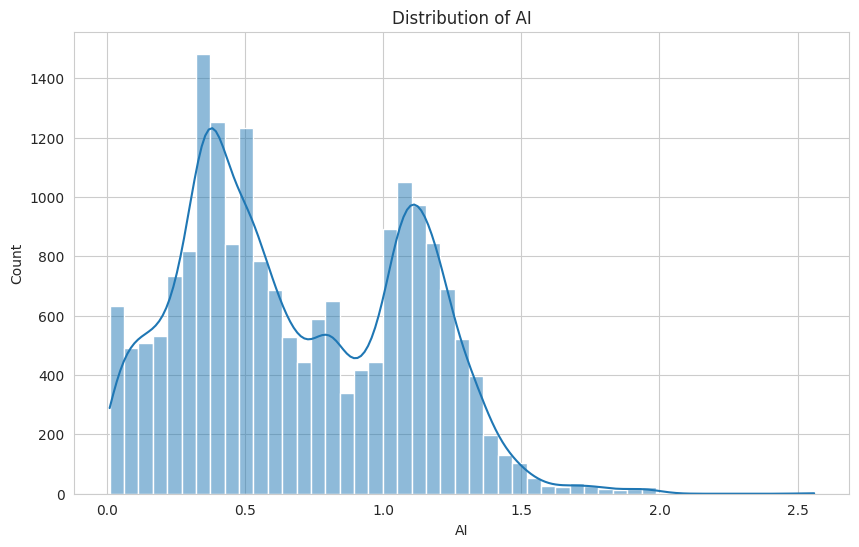

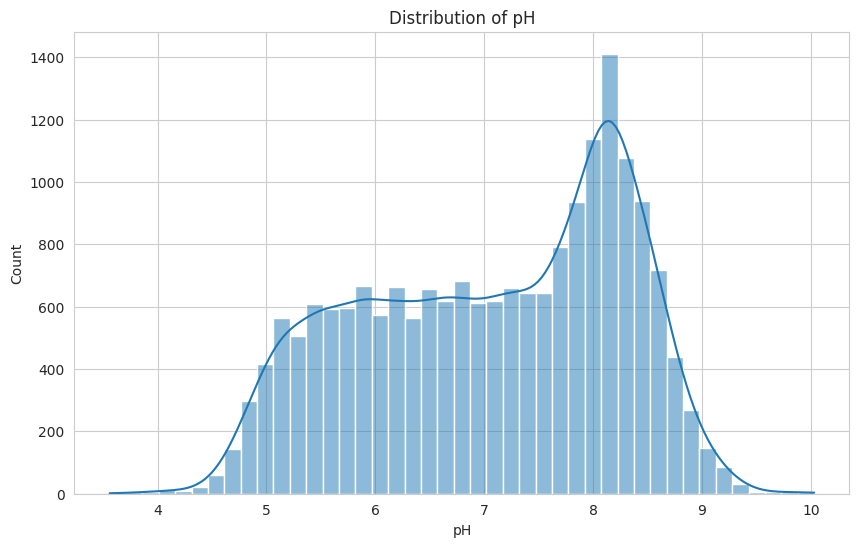

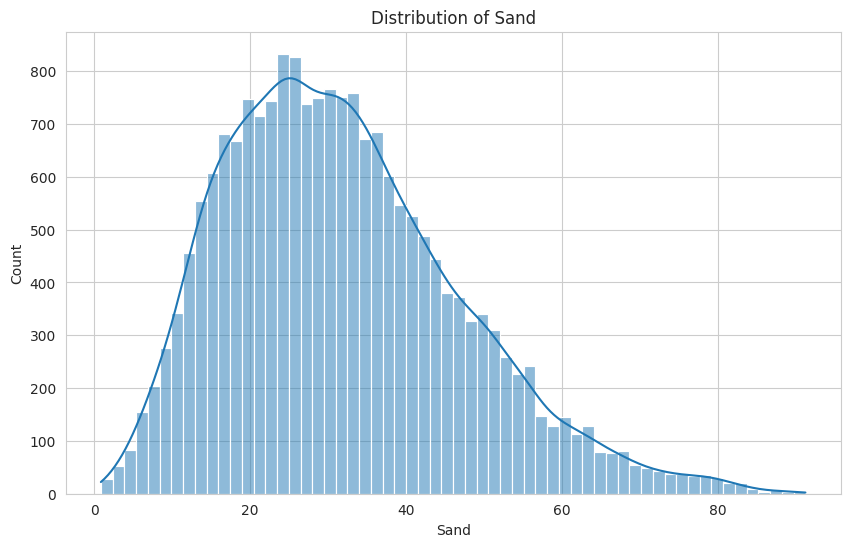

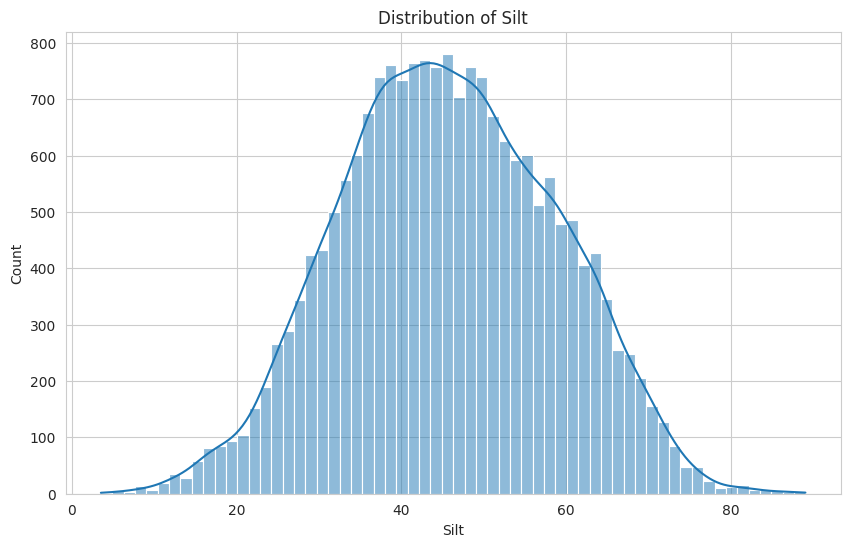

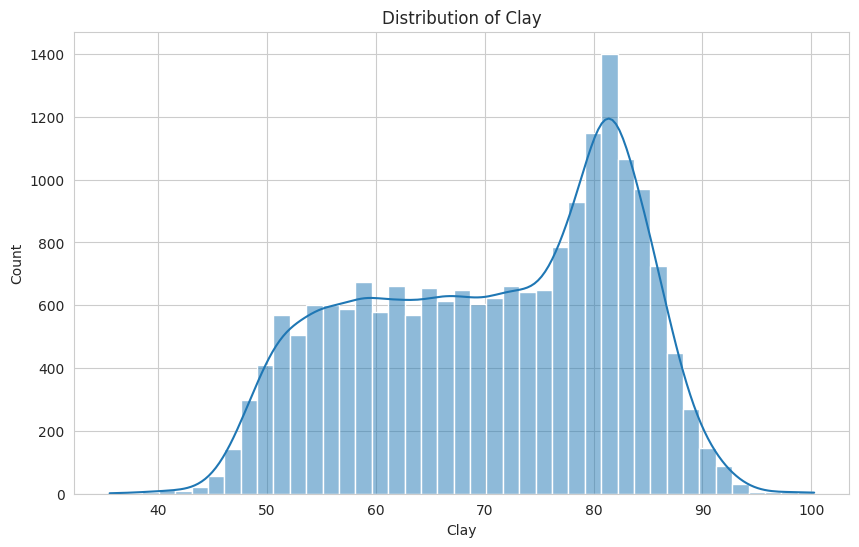

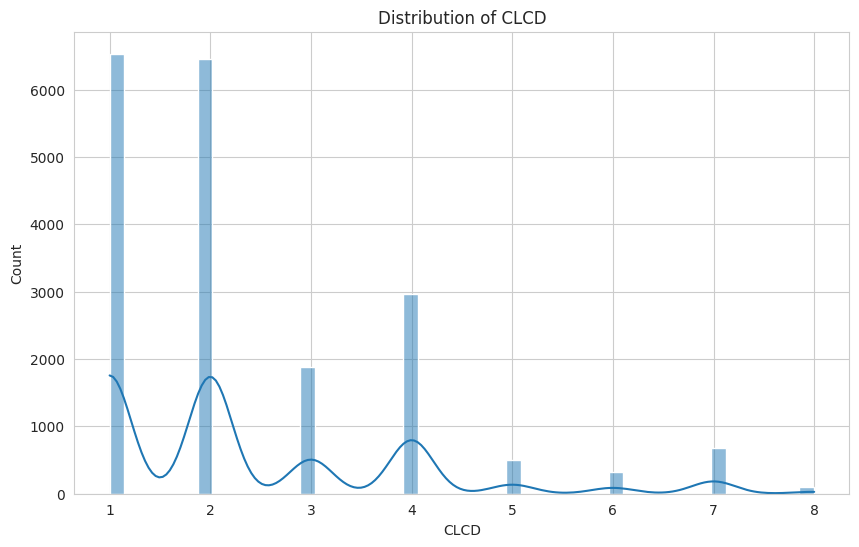

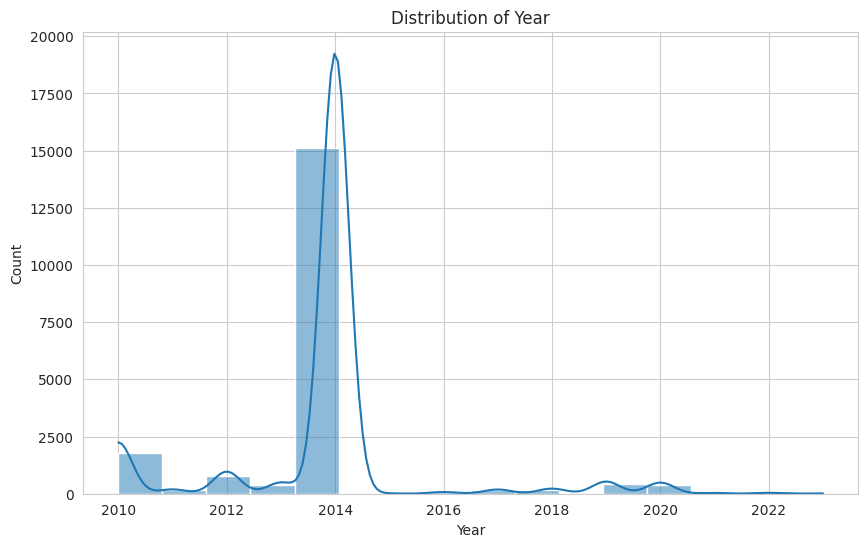

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

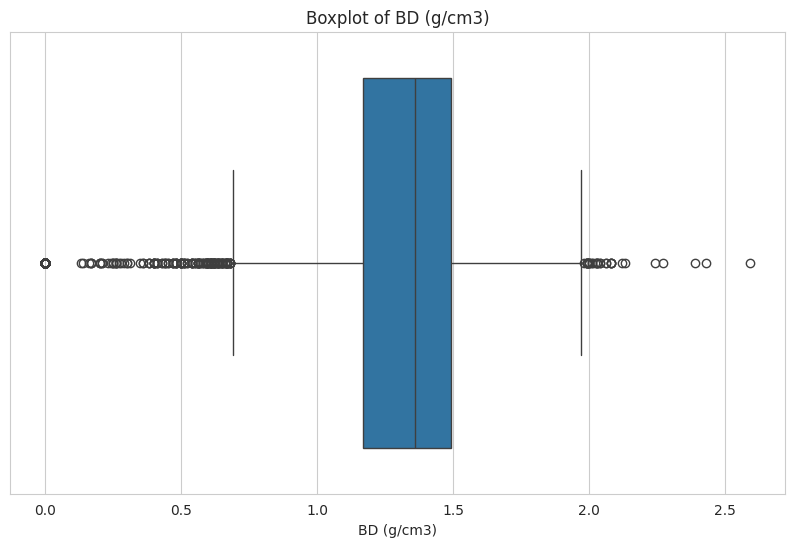

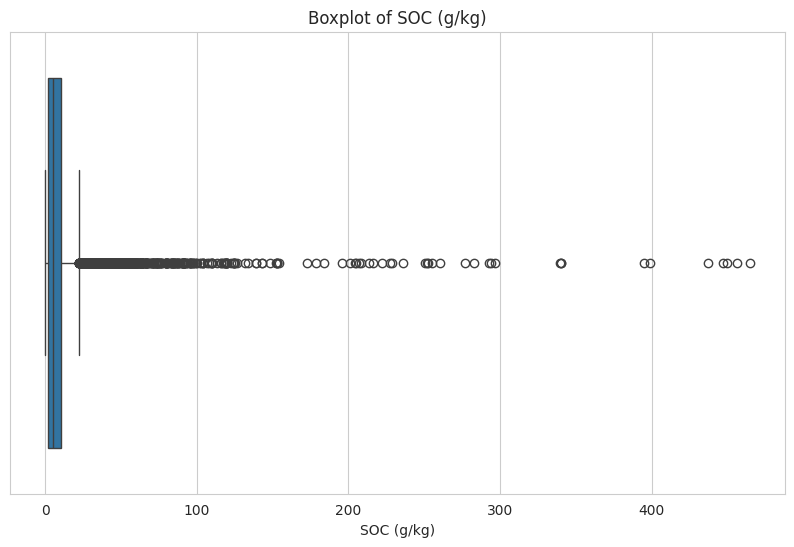

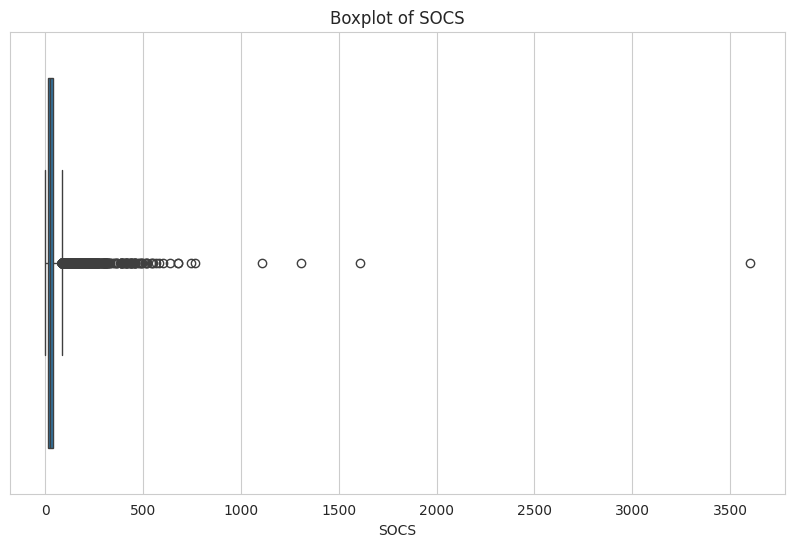

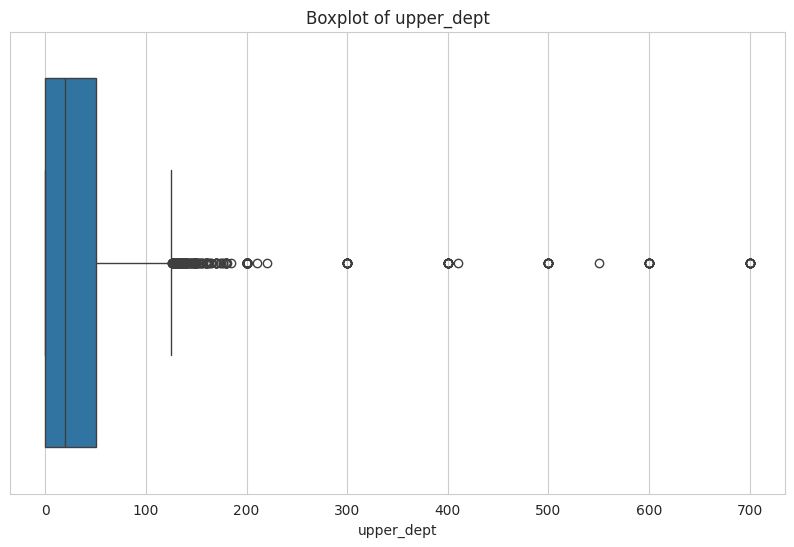

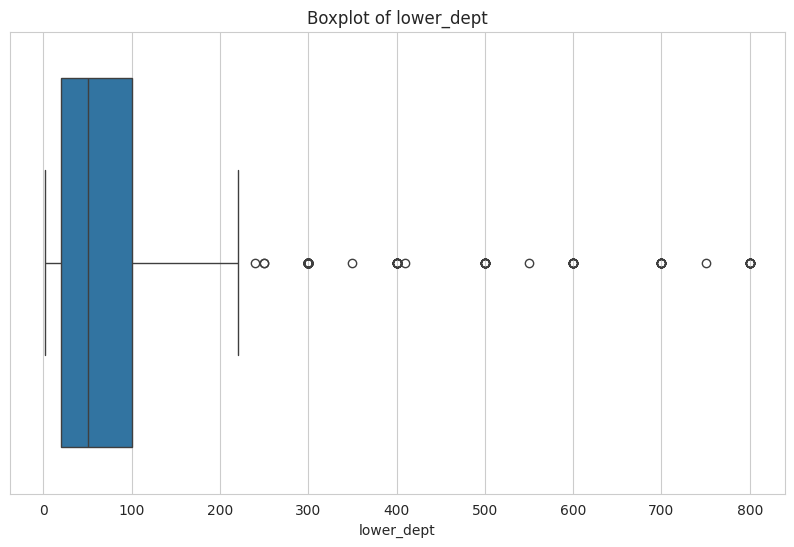

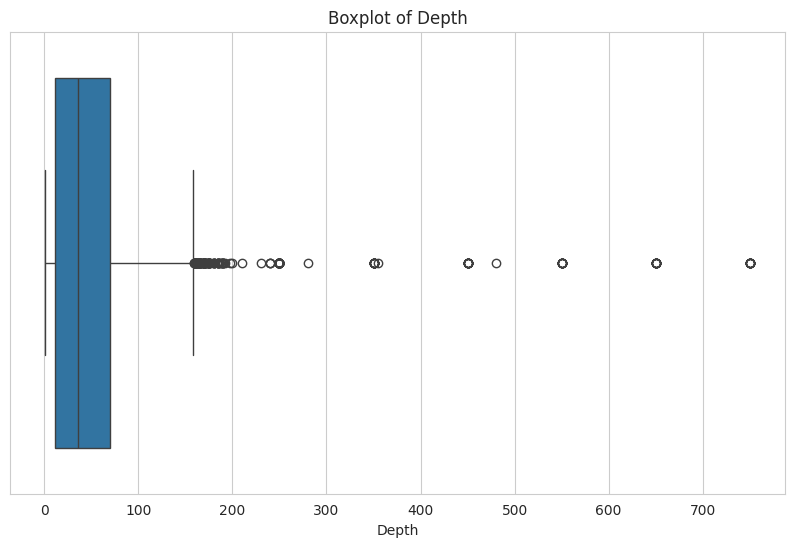

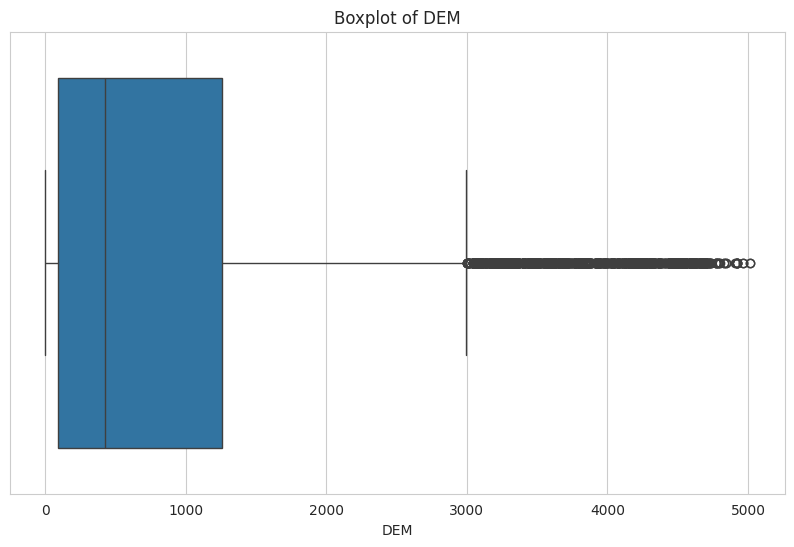

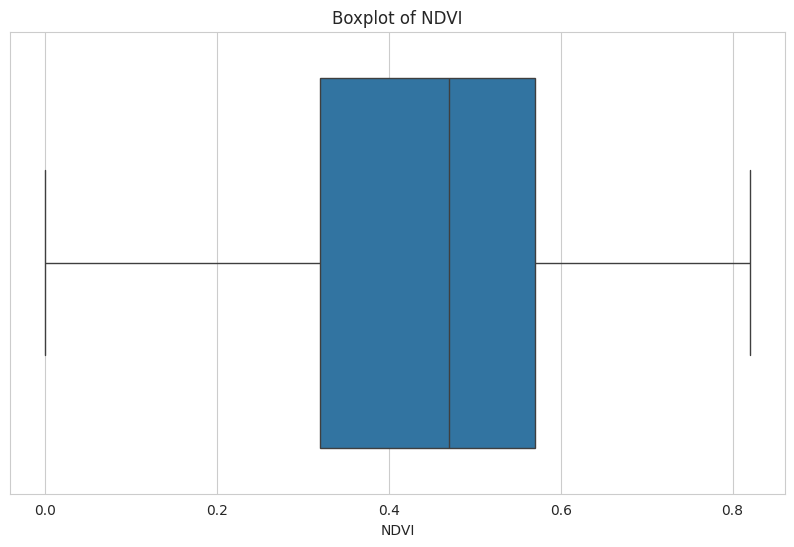

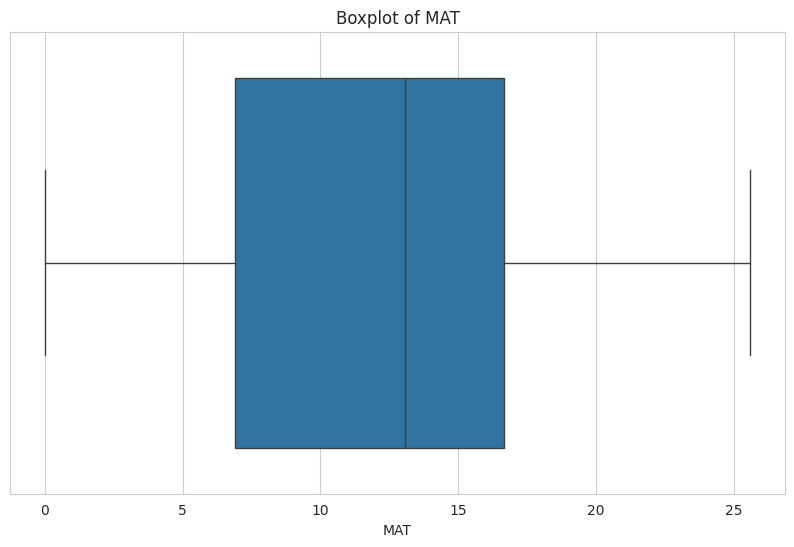

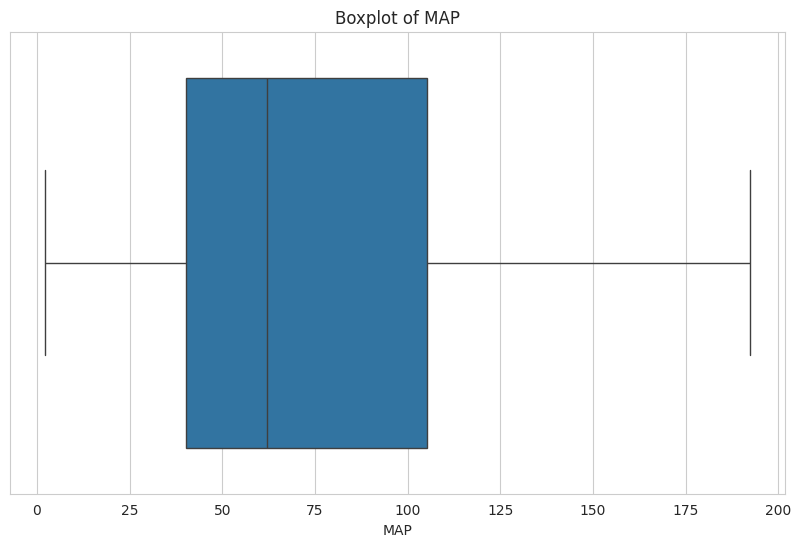

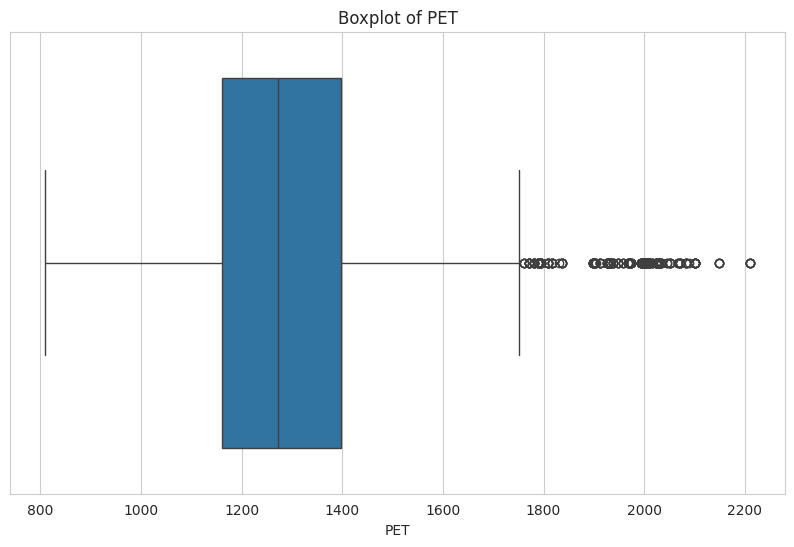

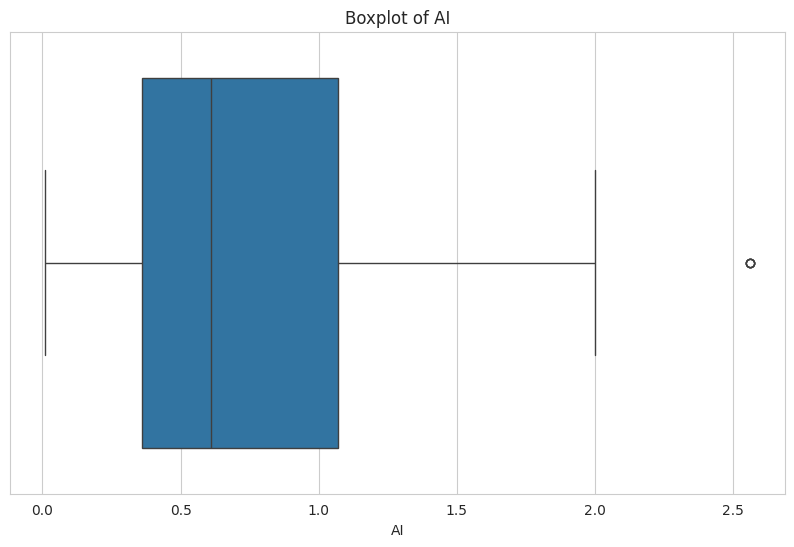

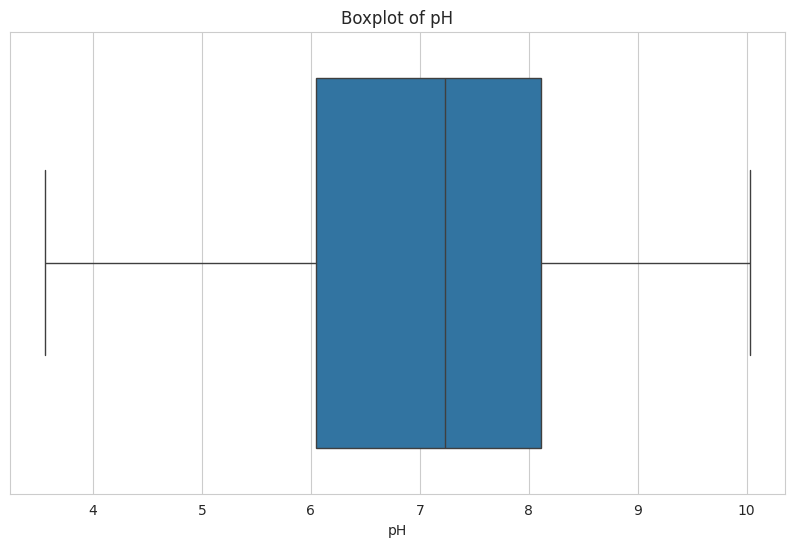

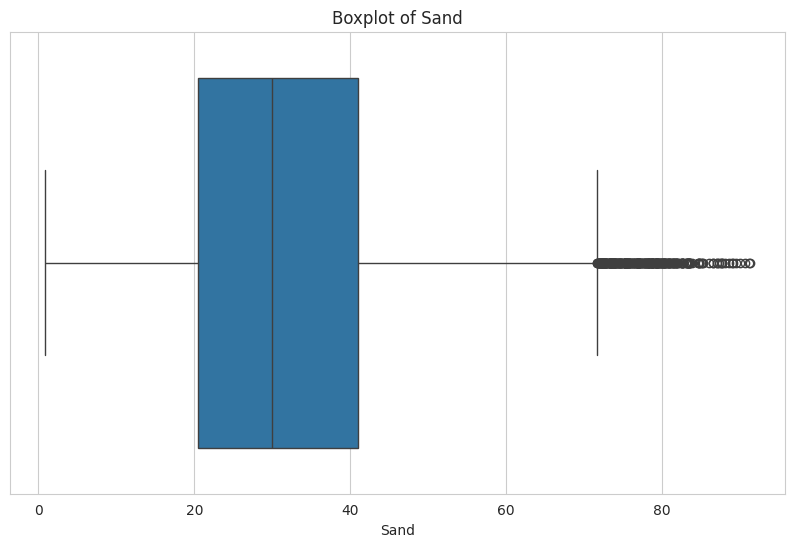

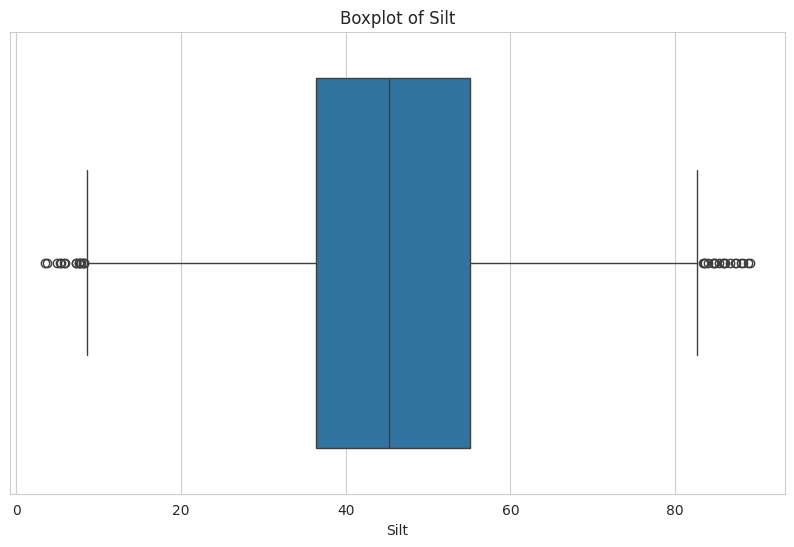

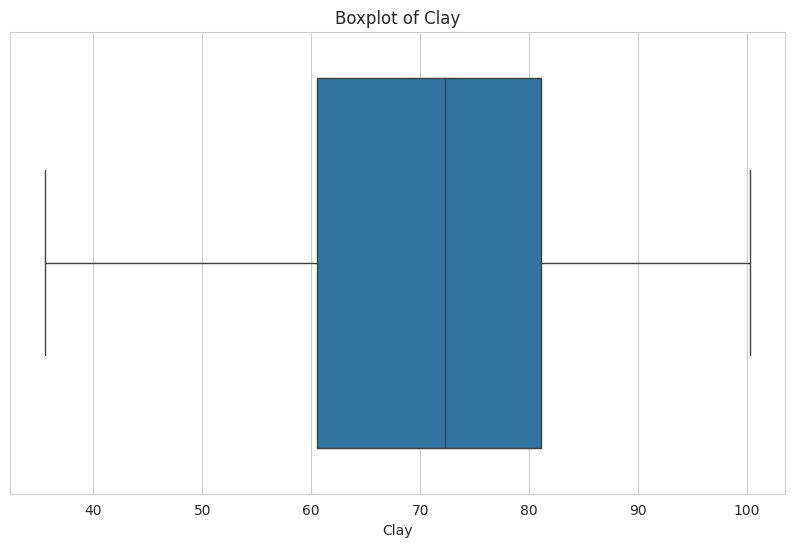

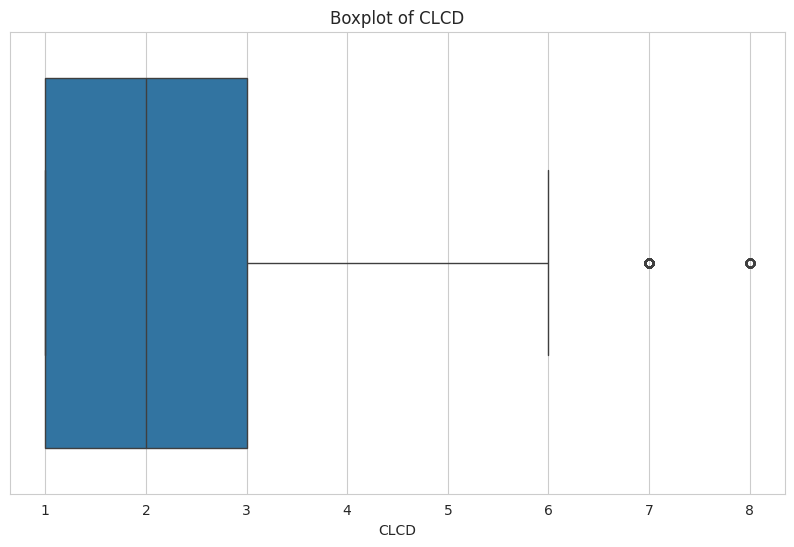

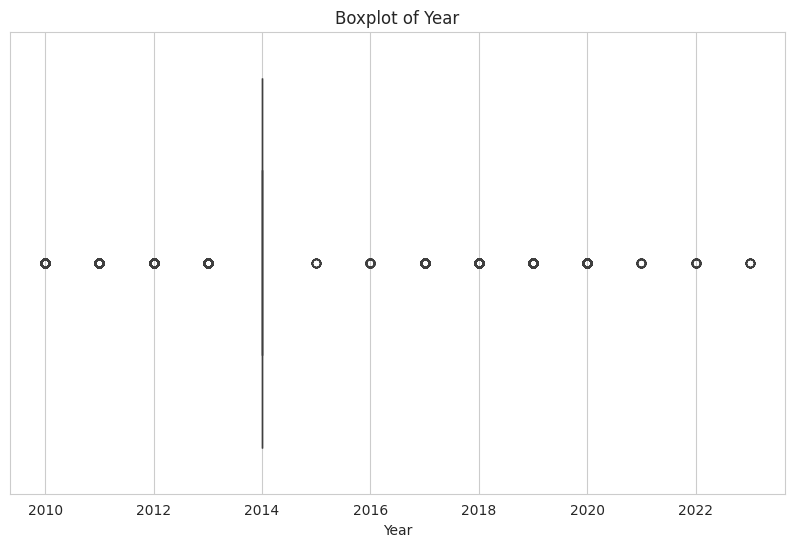

In [ ]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
df["upper_dept"] = df["upper_dept"].clip(upper=200)
df["lower_dept"] = df["lower_dept"].clip(upper=300)
df["Depth"] = df["Depth"].clip(upper=200)

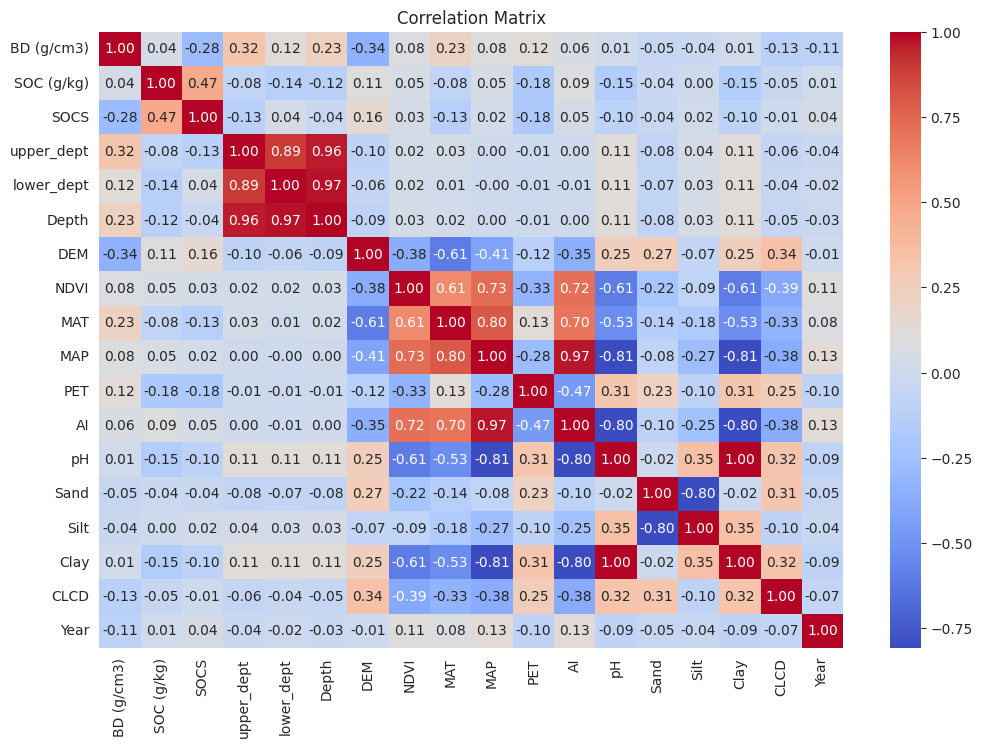

In [ ]:
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

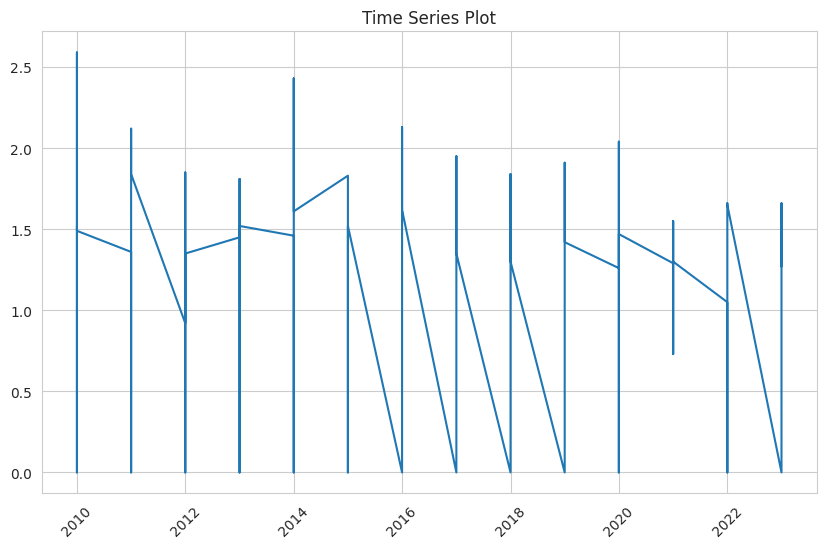

In [ ]:
if 'Year' in df.columns:
    df['Year'] = pd.to_datetime(df['Year'], format='%Y') # Assuming 'Year' is just the year
    df = df.sort_values('Year')

    plt.figure()
    plt.plot(df['Year'], df[num_cols[0]])
    plt.title("Time Series Plot")
    plt.xticks(rotation=45)
    plt.show()

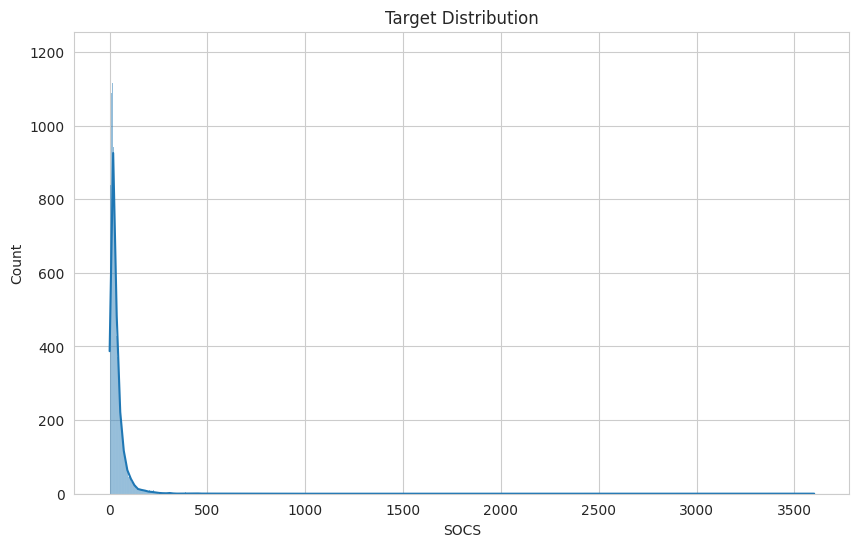

In [ ]:
target = "SOCS"

plt.figure()
sns.histplot(df[target], kde=True)
plt.title("Target Distribution")
plt.show()

<h1> Modeling

In [ ]:
target = "SOCS"

X = df.drop(columns=[target])
y = df[target]

print("Jumlah fitur:", X.shape[1])
print("Jumlah data:", X.shape[0])

Jumlah fitur: 18
Jumlah data: 19438


In [ ]:
if "Year" in X.columns:
    X["Year"] = X["Year"].dt.year

cat_cols = X.select_dtypes(include=["object", "category"]).columns

X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (15550, 19)
Test size: (3888, 19)


<h1> XGBoost

In [ ]:
xgb_model = XGBRegressor(random_state=42)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

<h1> Random Forrest

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

<h1> Linear Regression

In [ ]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

<h1> Evaluasi

<h1> XGBoost

In [ ]:
y_pred = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Baseline XGBoost ===")
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)

=== Baseline XGBoost ===
RMSE : 22.294697275385495
MAE  : 8.543306984072165
R2   : 0.7844679597215293


In [ ]:
# Ambil importance
importance = xgb_model.feature_importances_

# Ambil nama fitur
feature_names = X_train.columns

# Buat dataframe
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Urutkan
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

feat_imp.head(20)

,Feature,Importance
13,Silt,0.333575
1,SOC (g/kg),0.171877
3,lower_dept,0.097002
17,SOCD__meth_Measurement,0.051801
0,BD (g/cm3),0.047957
2,upper_dept,0.039261
7,MAT,0.038015
9,PET,0.033614
11,pH,0.030392
12,Sand,0.029624


In [ ]:
threshold = 0.025

selected_features = feat_imp[
    feat_imp["Importance"] > threshold
]["Feature"].values

print("Jumlah fitur terpilih:", len(selected_features))

Jumlah fitur terpilih: 12


In [ ]:
# Filter fitur
X_train_fs = X_train[selected_features]
X_test_fs  = X_test[selected_features]

# Model baseline lagi (default)
xgb_fs = XGBRegressor(random_state=42)

xgb_fs.fit(X_train_fs, y_train)

# Evaluasi
y_pred_fs = xgb_fs.predict(X_test_fs)

rmse_fs = np.sqrt(mean_squared_error(y_test, y_pred_fs))
mae_fs  = mean_absolute_error(y_test, y_pred_fs)
r2_fs   = r2_score(y_test, y_pred_fs)

print("=== Setelah Feature Selection ===")
print("RMSE :", rmse_fs)
print("MAE  :", mae_fs)
print("R2   :", r2_fs)

=== Setelah Feature Selection ===
RMSE : 21.53519700305782
MAE  : 8.243825969057543
R2   : 0.7989026356367379


<h1> Random Forrest

In [ ]:
y_pred = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Baseline Random Forest ===")
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)

In [ ]:
# Ambil importance
importance = rf_model.feature_importances_

# Ambil nama fitur
feature_names = X_train.columns

# Buat dataframe
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Urutkan
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

feat_imp.head(20)

In [ ]:
threshold = 0.02

selected_features = feat_imp[
    feat_imp["Importance"] > threshold
]["Feature"].values

print("Jumlah fitur terpilih:", len(selected_features))

In [ ]:
# Filter fitur
X_train_fs = X_train[selected_features]
X_test_fs  = X_test[selected_features]

# Model baseline lagi (default)
rf_fs = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_fs.fit(X_train_fs, y_train)

# Evaluasi
y_pred_fs = rf_fs.predict(X_test_fs)

rmse_fs = np.sqrt(mean_squared_error(y_test, y_pred_fs))
mae_fs  = mean_absolute_error(y_test, y_pred_fs)
r2_fs   = r2_score(y_test, y_pred_fs)

print("=== Setelah Feature Selection (Random Forest) ===")
print("RMSE :", rmse_fs)
print("MAE  :", mae_fs)
print("R2   :", r2_fs)

<h1> Linear Regression

In [ ]:
y_pred = lr_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Baseline Linear Regression ===")
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)

In [ ]:
# Ambil importance
importance = np.abs(lr_model.coef_)

# Ambil nama fitur
feature_names = X_train.columns

# Buat dataframe
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Urutkan
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

feat_imp.head(20)

In [ ]:
# Filter fitur
X_train_fs = X_train[selected_features]
X_test_fs  = X_test[selected_features]

# Model baseline lagi (default)
lr_fs = LinearRegression()

rf_fs.fit(X_train_fs, y_train)

# Evaluasi
y_pred_fs = lr_fs.predict(X_test_fs)

rmse_fs = np.sqrt(mean_squared_error(y_test, y_pred_fs))
mae_fs  = mean_absolute_error(y_test, y_pred_fs)
r2_fs   = r2_score(y_test, y_pred_fs)

print("=== Setelah Feature Selection (Random Forest) ===")
print("RMSE :", rmse_fs)
print("MAE  :", mae_fs)
print("R2   :", r2_fs)

<h1> Simpan Model

In [ ]:
joblib.dump(xgb_fs, "XGBoost_baseline.pkl")

print("Model baseline berhasil disimpan.")

Model baseline berhasil disimpan.


In [ ]:
joblib.dump(rf_model, "Random_Forrest_baseline.pkl")

print("Model baseline berhasil disimpan.")

Model baseline berhasil disimpan.


In [ ]:
joblib.dump(lr_model, "Linear_Regression_baseline.pkl")

print("Model baseline berhasil disimpan.")

Model baseline berhasil disimpan.


<h1> Hyperparameter Tuning

In [ ]:
param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

In [ ]:
xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

In [ ]:
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


KeyboardInterrupt: 

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

best_xgb = grid_search.best_estimator_

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred_tuned = best_xgb.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned   = r2_score(y_test, y_pred_tuned)

print("=== Tuned XGBoost ===")
print("RMSE :", rmse_tuned)
print("MAE  :", mae_tuned)
print("R2   :", r2_tuned)